# Getting started with insurabench

A walkthrough of the primary operations in the libary: load your own
policy and claims data, fit a model, check how well it performs, and pull a
couple of standard rating charts.

First, run `pip install -e .` from the repo root first if you haven't already.


## Loading Policy and Claims Data from Two CSVs

By design insurabench always works from two separate tables (policies and claims), see
`data/README.md` for what these sample files look like.
Describe the columns once with `PolicySchema` and `ClaimsSchema`, load
both tables, and combine them into a single `PolicyFrame`.
Every other insurabench function works with this object. 


In [ ]:
import pandas as pd

from insurabench.data.schema import ClaimsSchema, FeatureRole, PolicySchema
from insurabench.policies.loader import load_policies
from insurabench.claims.loader import load_claims
from insurabench.data.policy_frame import PolicyFrame

policy_schema = PolicySchema(
    policy_id_col="policy_id",
    exposure_col="exposure",
    term_start_col="term_start",
    term_end_col="term_end",
    premium_col="premium",
    feature_roles={
        "vehicle_power": FeatureRole.CONTINUOUS,
        "driver_age": FeatureRole.CONTINUOUS,
        "vehicle_brand": FeatureRole.CATEGORICAL,
        "region": FeatureRole.CATEGORICAL,
    },
)
claims_schema = ClaimsSchema(
    claim_id_col="claim_id",
    policy_id_col="policy_id",
    claim_date_col="claim_date",
    claim_amount_col="claim_amount",
    peril_col="peril",
    coverage_col="coverage",
)

# dates must be parsed before loading -- a plain pd.read_csv() leaves them
# as strings, and insurabench will (deliberately) refuse to guess.
policies_df = pd.read_csv("data/sample_policies.csv", parse_dates=["term_start", "term_end"])
claims_df = pd.read_csv("data/sample_claims.csv", parse_dates=["claim_date"])

policies = load_policies(policies_df, policy_schema)
claims = load_claims(claims_df, claims_schema)

pf = PolicyFrame.from_tables(policies, claims, policy_schema, claims_schema)


`pf` is now the one object every other insurabench function operates on.
See `pf.describe()` any time to view the basic shape of the book and 
the message of how a PolicyFrame is defined. 


In [2]:
print(pf.describe())

PolicyFrame: 414 policy-period(s), 89 claim(s), 267.8 total exposure.
Feature roles: {'vehicle_power': <FeatureRole.CONTINUOUS: 'continuous'>, 'driver_age': <FeatureRole.CONTINUOUS: 'continuous'>, 'vehicle_brand': <FeatureRole.CATEGORICAL: 'categorical'>, 'region': <FeatureRole.CATEGORICAL: 'categorical'>}
insurabench treats claim amounts as final/as-of snapshot values: there is no paid/incurred/reserved distinction and no claim-development modeling. If your claims are still maturing, finalize/aggregate them upstream first (design brief §3.4, §9.6).


## Fitting a Frequency Model

Split the data into train and test, fit the Poisson GLM to the claim data,
and then check with the goodness-of-fit meausure D^2, the Gini index and
then calibration index.

Note that the sample book is small and results only illustrative, there
are only 89 claims in total in the dataset. See Notebook 2 for a worked
example with a much larger policy and claims book.


In [3]:
from insurabench.model_selection import train_test_split_policy_frame
from insurabench.models.glm import GLMPricingModel
from insurabench.evaluation import gini_index, calibration_index

train_pf, test_pf = train_test_split_policy_frame(pf, test_size=0.2, seed=0)

model = GLMPricingModel(family="poisson").fit_policy_frame(train_pf, "frequency")
y_pred = model.predict_policy_frame(test_pf)

print(f"Test D²:            {model.score_policy_frame(test_pf):.3f}")
print(f"Gini:               {gini_index(test_pf, 'frequency', y_pred):.3f}")
print(f"Calibration index:  {calibration_index(test_pf, 'frequency', y_pred):.3f}")


Test D²:            -0.021
Gini:               0.041
Calibration index:  1.176


## Lift Chart

A `lift_chart` buckets policies into deciles by predicted rate (weighted by
*exposure*) and then compares actual vs. predicted in each.
The function`plot_lift_chart` produces the chart.


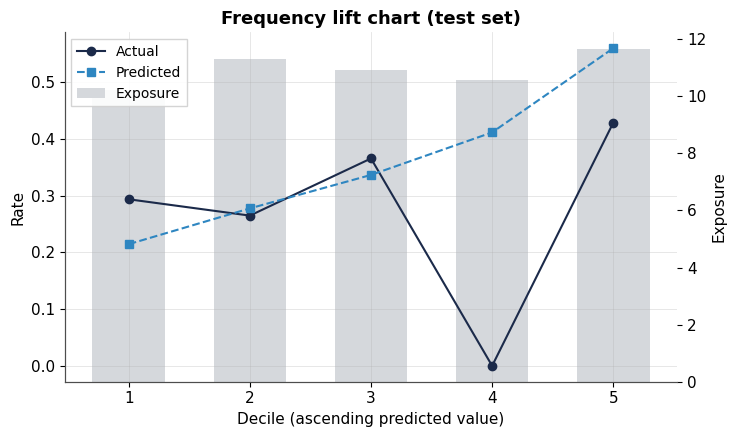

,decile,n_obs,exposure,actual,predicted
0,1,15,10.210,0.293830,0.214638
1,2,18,11.320,0.265018,0.277760
2,3,16,10.934,0.365831,0.336770
3,4,16,10.566,0.000000,0.411825
4,5,18,11.658,0.428890,0.560316


In [4]:
from insurabench.evaluation import lift_chart
from insurabench.viz import plot_lift_chart

chart = lift_chart(test_pf, "frequency", y_pred, n_deciles=5)
plot_lift_chart(chart, title="Frequency lift chart (test set)")
chart


## One Way Curve for Examining a Rating Factor

The `one_way_curve` gives the standard actual-vs-fitted-by-level view for
a rating factor, with a confidence band and exposure shown as
background bars. The function `plot_one_way_curve` produces it.

The small claims dataset used here makes the confidence band very large, 
see Notebook 2 for a more realistic example.


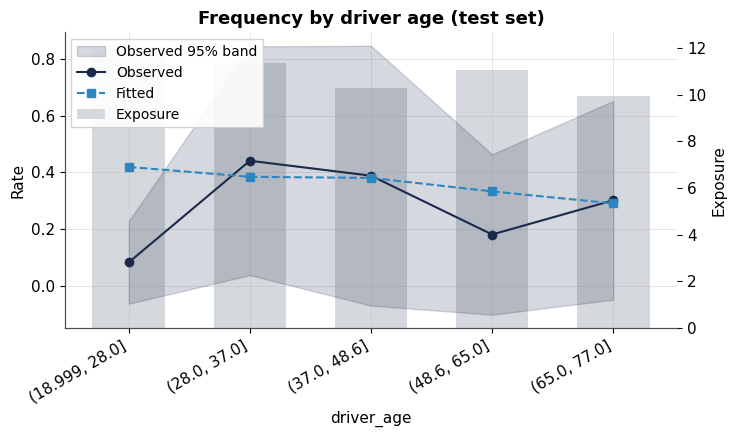

,level,n_obs,exposure,observed,observed_lower,observed_upper,fitted
0,"(18.999, 28.0]",18,12.066,0.082878,-0.062863,0.228618,0.419145
1,"(28.0, 37.0]",17,11.336,0.441073,0.037954,0.844192,0.384419
2,"(37.0, 48.6]",15,10.300,0.388350,-0.069473,0.846172,0.380570
3,"(48.6, 65.0]",17,11.042,0.181127,-0.101502,0.463756,0.332970
4,"(65.0, 77.0]",16,9.944,0.301689,-0.048639,0.652018,0.290601


In [5]:
from insurabench.curves import one_way_curve
from insurabench.viz import plot_one_way_curve

curve = one_way_curve(test_pf, "driver_age", "frequency", y_pred, n_bins=5)
plot_one_way_curve(curve, feature_name="driver_age", title="Frequency by driver age (test set)")
curve


## Where next

- **`02_model_agnostic_pricing.ipynb`** - the same curves/evaluation
  worked example as above, run unchanged against a GLM *and* a GBM, but on a much larger book.
- **`03_pricing_the_whole_book.ipynb`** - getting from the fitted frequency +
  severity to a full pure-premium price, in two different ways.
- **`04_from_model_to_deliverables.ipynb`** - turning a fitted model
  into a one-page model evaluation card and an exportable rating table.
